## Task 1: Problem Identification

The given dataset represents an **Image Classification** problem.

Each image belongs to one of the predefined categories:
- normal
- scratch
- dent
- stain

The goal is to classify each image into one of these four classes based on the visual patterns present in the image.

This is not an object detection or segmentation problem because:
- There is no requirement to locate objects using bounding boxes.
- There is no need for pixel-level labeling.
- Each image has only one label.

Therefore, image classification is the most appropriate problem formulation for this dataset.

## Task 2: Dataset Exploration

In this task, we analyze the dataset to understand:
- Number of classes
- Number of images per class
- Sample images
- Image dimensions
- Dataset balance

In [86]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [87]:
dataset_path = "/content/drive/MyDrive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/images"

In [88]:
import os

classes = os.listdir(dataset_path)

# remove unwanted file
classes = [cls for cls in classes if cls != '.DS_Store']

print("Classes:", classes)

Classes: ['stain', 'normal', 'dent', 'scratch']


The dataset contains four classes: normal, scratch, dent, and stain.

In [89]:
for cls in classes:
    path = os.path.join(dataset_path, cls)
    print(cls, ":", len(os.listdir(path)))

stain : 120
normal : 120
dent : 120
scratch : 120


Each class contains 120 images, indicating a balanced dataset.

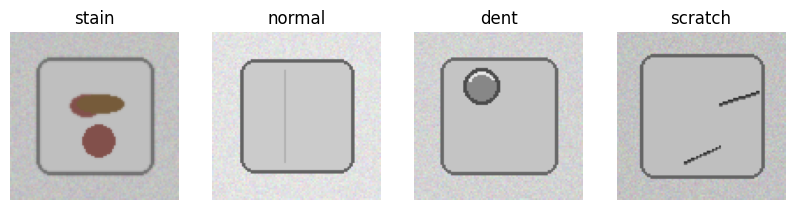

In [90]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(10, 5))

for i, cls in enumerate(classes):
    path = os.path.join(dataset_path, cls)

    img_name = os.listdir(path)[0]   # first image
    img_path = os.path.join(path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

Sample images from each class were visualized to understand the dataset.

Each category (normal, scratch, dent, stain) shows distinct visual patterns:
- Normal images have clean surfaces
- Scratch images show line-based damage
- Dent images show circular deformation
- Stain images show irregular colored patches

This confirms that the dataset is suitable for an image classification problem.

In [91]:
import cv2

# pick one sample image
sample_class = classes[0]
sample_path = os.path.join(dataset_path, sample_class)
sample_image = os.listdir(sample_path)[0]

img = cv2.imread(os.path.join(sample_path, sample_image))

print("Image Shape:", img.shape)

Image Shape: (96, 96, 3)


All images have a consistent size of 96x96 with 3 color channels (RGB).

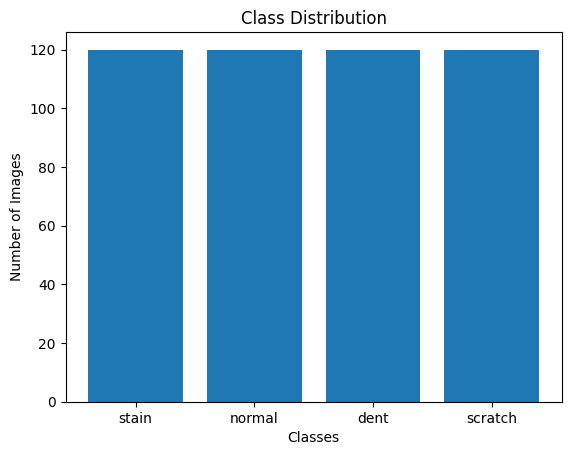

In [92]:
import matplotlib.pyplot as plt

class_counts = []

for cls in classes:
    path = os.path.join(dataset_path, cls)
    count = len(os.listdir(path))
    class_counts.append(count)

plt.bar(classes, class_counts)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

The bar chart confirms that all classes have equal distribution, so there is no class imbalance.

## Task 3: Image Preprocessing

In this task, we prepare the dataset for CNN training by:
- Resizing images
- Normalizing pixel values
- Splitting data into training and testing sets
- Applying data augmentation

In [93]:
import numpy as np
import cv2
import os

IMG_SIZE = 64   # CNN ke liye fixed size

data = []
labels = []

for cls in classes:
    path = os.path.join(dataset_path, cls)
    label = classes.index(cls)  # convert class to number

    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)

        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        data.append(img)
        labels.append(label)

# convert to numpy array
X = np.array(data)
y = np.array(labels)

print("Data shape:", X.shape)
print("Labels shape:", y.shape)

Data shape: (480, 64, 64, 3)
Labels shape: (480,)


Images were loaded and resized to a fixed size of 64x64 pixels.

Each class was assigned a numerical label for model training:
- normal → 0
- scratch → 1
- dent → 2
- stain → 3

The dataset was converted into NumPy arrays for efficient processing.

In [94]:
X = X / 255.0

Pixel values were normalized from the range [0, 255] to [0, 1].

This helps the neural network train faster and improves performance.

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (384, 64, 64, 3)
Test shape: (96, 64, 64, 3)


The dataset was split into training and testing sets using an 80-20 ratio.

Training data is used to train the model, while testing data is used to evaluate its performance.

In [96]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

Data augmentation techniques such as rotation, zoom, and flipping were applied to increase dataset diversity and improve model generalization.

## Task 4: CNN Model Creation

In this task, we build a Convolutional Neural Network (CNN) model to classify images into four categories: normal, scratch, dent, and stain.

The model includes:
- Convolution layers to extract features
- Activation functions (ReLU)
- Pooling layers to reduce dimensions
- Flatten layer to convert feature maps into vectors
- Dense layers for classification

In [97]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

# Convolution Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))
model.add(MaxPooling2D(2,2))

# Convolution Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(64, activation='relu'))

# Output Layer (4 classes)
model.add(Dense(4, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,532 (3.14 MB)

 Trainable params: 822,532 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

The CNN model consists of two convolutional layers followed by pooling layers.

Convolution layers help in extracting important features from images, while pooling reduces the spatial size.

The flattened output is passed through dense layers, and finally a softmax layer is used for multi-class classification.

In [98]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

The model is compiled using the Adam optimizer and sparse categorical crossentropy loss function.

Accuracy is used as the evaluation metric.

## Task 5: Model Training and Evaluation

In this task, we train the CNN model and evaluate its performance using:
- Training and validation accuracy
- Training and validation loss
- Test accuracy
- Confusion matrix
- Sample predictions

In [99]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 181ms/step - accuracy: 0.2422 - loss: 1.5357 - val_accuracy: 0.3021 - val_loss: 1.3759
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 0.2214 - loss: 1.3931 - val_accuracy: 0.2708 - val_loss: 1.3871
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 292ms/step - accuracy: 0.3073 - loss: 1.3809 - val_accuracy: 0.2396 - val_loss: 1.3825
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step - accuracy: 0.3229 - loss: 1.3697 - val_accuracy: 0.3125 - val_loss: 1.3711
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step - accuracy: 0.3516 - loss: 1.3340 - val_accuracy: 0.4167 - val_loss: 1.3202
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step - accuracy: 0.4766 - loss: 1.2434 - val_accuracy: 0.4062 - val_loss: 1.2314
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step - accuracy: 0.5859 - loss: 1.1048 - val_accuracy: 0.5521 - val_loss: 1.1164
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.6328 - loss: 0.9957 - val_accuracy: 0.

The model was trained for multiple epochs, and validation data was used to monitor performance on unseen data.

In [100]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6458 - loss: 0.8737
Test Accuracy: 0.6458333134651184
Test Loss: 0.8737104535102844


The model was evaluated on the test dataset to measure its performance.

Test accuracy indicates how well the model generalizes to unseen data.

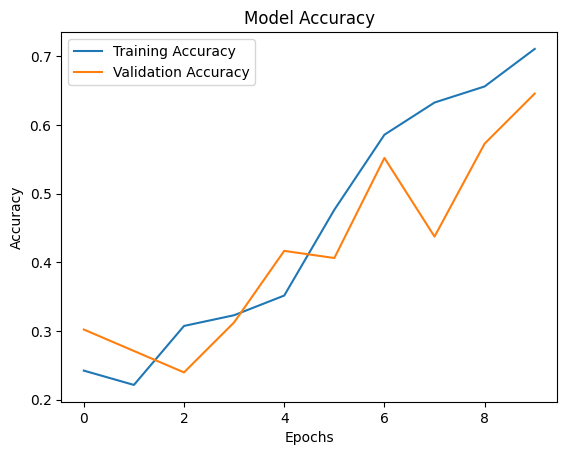

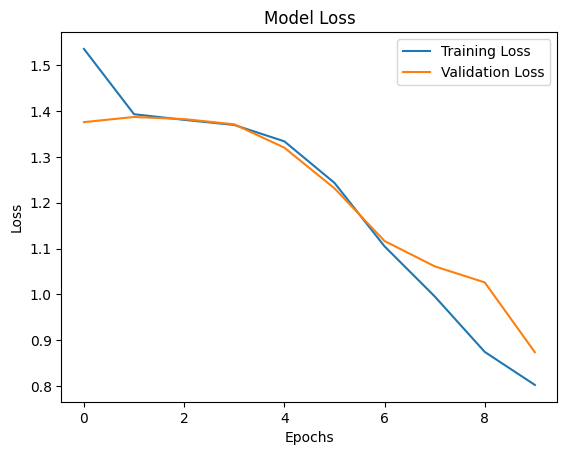

In [101]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

The accuracy and loss curves show how the model improves over time.

A small gap between training and validation curves indicates good generalization.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


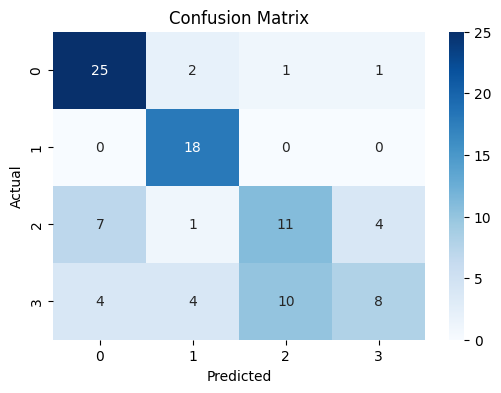

In [102]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows the performance of the model across different classes.

It helps identify which classes are being misclassified.

In [103]:
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.69      0.86      0.77        29
           1       0.72      1.00      0.84        18
           2       0.50      0.48      0.49        23
           3       0.62      0.31      0.41        26

    accuracy                           0.65        96
   macro avg       0.63      0.66      0.63        96
weighted avg       0.63      0.65      0.62        96



The classification report provides precision, recall, and F1-score for each class.

These metrics give a deeper understanding of model performance.